In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [3]:
# 1. Simulate an AR(2) Process
# Equation: y_t = 0.75y_{t-1} - 0.25y_{t-2} + e_t
np.random.seed(42)
ar_coefs = np.array([1, -0.75, 0.25]) # Statsmodels notation
ma_coefs = np.array([1])

ar2_process = ArmaProcess(ar_coefs, ma_coefs)
simulated_data = ar2_process.generate_sample(nsample=200)

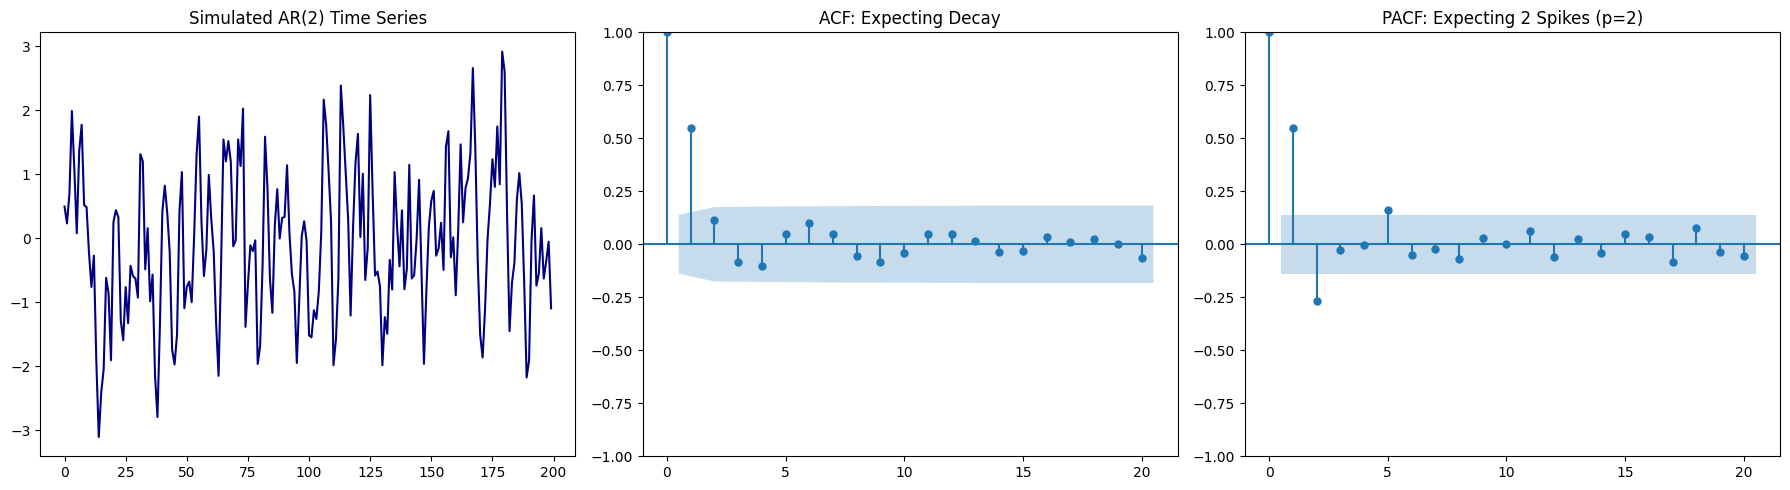

In [4]:
# 2. Plotting the Time Series, ACF, and PACF
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot the raw data
axes[0].plot(simulated_data, color='navy')
axes[0].set_title('Simulated AR(2) Time Series')

# Plot the ACF
# For an AR model, ACF should tail off (geometric decay)
plot_acf(simulated_data, alpha=0.05, ax=axes[1], lags=20)
axes[1].set_title('ACF: Expecting Decay')

# Plot the PACF
# For an AR(2) model, PACF should have 2 significant spikes then cut off
plot_pacf(simulated_data, alpha=0.05, ax=axes[2], lags=20, method='ywm')
axes[2].set_title('PACF: Expecting 2 Spikes (p=2)')

plt.tight_layout()
plt.show()


2. CRITERION-BASED MODEL SELECTION

AIC

BIC


In [5]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA


In [6]:
# 1. Simulate Data: AR(2) Process
# Equation: y_t = 0.5y_{t-1} - 0.3y_{t-2} + e_t
np.random.seed(42)
ar_params = np.array([1, -0.5, 0.3]) # Note: statsmodels uses opposite signs for AR
ma_params = np.array([1])
process = ArmaProcess(ar_params, ma_params)
data = process.generate_sample(nsample=200)
data


array([ 4.96714153e-01,  1.10092775e-01,  5.53720680e-01,  1.76686236e+00,
        4.83161603e-01, -5.22614864e-01,  1.17295690e+00,  1.51069764e+00,
       -6.60126368e-02,  5.63444333e-02, -4.15441685e-01, -6.90353926e-01,
        2.14178140e-02, -1.69546516e+00, -2.57907576e+00, -1.34318586e+00,
       -9.10701323e-01,  2.61852429e-01, -5.03887464e-01, -1.74280316e+00,
        7.45413427e-01,  6.69771362e-01,  1.78789857e-01, -1.53628467e+00,
       -1.36616201e+00, -1.11273018e-01, -7.96781482e-01,  1.06891827e-02,
       -3.56259654e-01, -4.73030332e-01, -7.31343882e-01,  1.62851534e+00,
        1.02016361e+00, -1.03618373e+00, -1.59603440e-03, -9.10786549e-01,
       -2.46050869e-01, -1.80945959e+00, -2.15910058e+00, -3.39851178e-01,
        1.21627117e+00,  8.81459218e-01, -3.98000233e-02, -5.85441473e-01,
       -1.75930272e+00, -1.42386313e+00, -6.44779518e-01,  1.16189141e+00,
        1.11799785e+00, -1.55260865e+00, -7.87619711e-01, -3.13109540e-01,
       -5.97190857e-01,  

In [7]:
# 2. Grid Search for Model Selection
results_list = []
p_range = range(0, 4) # AR terms to test
q_range = range(0, 4) # MA terms to test

for p in p_range:
    for q in q_range:
        try:
            # We assume d=0 since we simulated stationary data
            model = ARIMA(data, order=(p, 0, q))
            model_fit = model.fit()
            results_list.append({
                'Order': f'ARIMA({p},0,{q})',
                'AIC': model_fit.aic,
                'BIC': model_fit.bic
            })
        except:
            continue


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Top 5 Models ranked by AIC:
           Order         AIC         BIC
15  ARIMA(3,0,3)  545.338421  571.724960
8   ARIMA(2,0,0)  545.529177  558.722447
11  ARIMA(2,0,3)  546.130429  569.218650
9   ARIMA(2,0,1)  546.425603  562.917190
12  ARIMA(3,0,0)  546.539795  563.031382


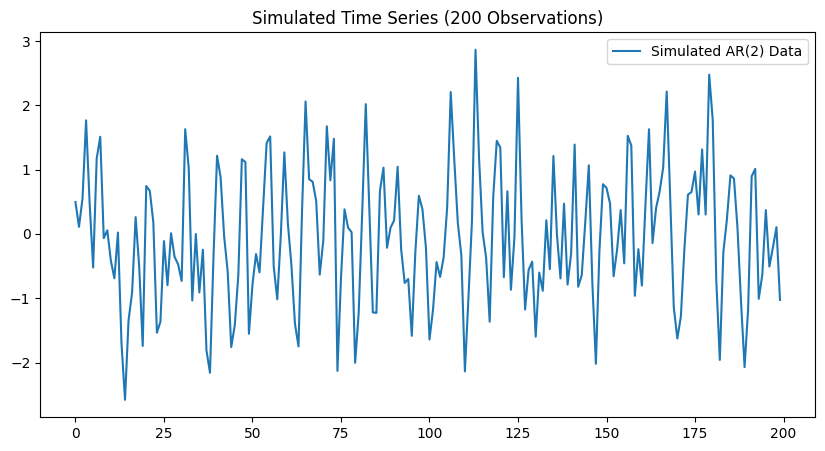

In [8]:
# 3. Compare Results
results_df = pd.DataFrame(results_list).sort_values(by='AIC')

print("Top 5 Models ranked by AIC:")
print(results_df.head())

# 4. Visualization
plt.figure(figsize=(10, 5))
plt.plot(data, label='Simulated AR(2) Data')
plt.title('Simulated Time Series (200 Observations)')
plt.legend()
plt.show()


Based on the ranked list, here is what to look for:

- The Winner: Look for the model with the lowest AIC. In this simulation, you should find that ARIMA(2,0,0) or ARIMA(2,0,1) ranks at the top because they closely match the true data-generating process.

- The Penalty: You might notice that BIC is higher than AIC. If you have two models with similar performance, BIC will almost always point you toward the simpler one (the one with fewer parameters).

- Stationarity: In the code above, differencing was set at zero, d=0. If this were real-world data, you would first check for a trend. If a trend existed, you would set d=1 and then run the grid search on the remaining p and q parameters.


3. AUTOMATING MODEL SELECTION

In [9]:
#!python3 -m pip uninstall pmdarima statsmodels scipy -y

In [10]:
#!python3 -m pip install scipy==1.11.4
#!python3 -m pip install statsmodels==0.14.1
#!python3 -m pip install pmdarima==2.0.4

In [11]:
#Libraries
import numpy as np
import pmdarima as pm
from pmdarima.datasets import load_airpassengers

In [12]:
# 1. Load or Generate Data
# Let's use the classic AirPassengers dataset (it has trend and seasonality)
data = load_airpassengers()
data

array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
       118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
       114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
       162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
       209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
       272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
       302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
       315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
       318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
       348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
       362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
       342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
       417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
       432.])

In [13]:
# 2. Automated Model Selection
# auto_arima handles: 
# - Differencing (d)
# - AR/MA terms (p, q)
# - Seasonality (P, D, Q, m)
model = pm.auto_arima(data, 
                      start_p=1, start_q=1,
                      max_p=3, max_q=3, # Limits the search for speed
                      m=12,             # Monthly data (seasonal cycle)
                      seasonal=True,    # Look for seasonal patterns
                      d=None,           # Let the algorithm choose 'd'
                      trace=True,       # Print the progress of the search
                      error_action='ignore', 
                      suppress_warnings=True, 
                      stepwise=True)    # Use the faster stepwise algorithm

print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1022.299, Time=0.74 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.70 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.39 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.54 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.08 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.46 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.21 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.35 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.45 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.29 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.09 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.44 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [14]:
# 3. Forecasting the next 12 months
forecast, conf_int = model.predict(n_periods=12, return_conf_int=True)
print(f"Best Model Order: {model.order}")
print(f"Best Seasonal Order: {model.seasonal_order}")


Best Model Order: (0, 1, 1)
Best Seasonal Order: (2, 1, 0, 12)
